In [1]:
from datascience import *
import numpy as np

%matplotlib inline
import matplotlib.pyplot as plt
plt.style.use('fivethirtyeight')

In [2]:
births = Table.read_table('data/baby.csv')
births

Birth Weight,Gestational Days,Maternal Age,Maternal Height,Maternal Pregnancy Weight,Maternal Smoker
120,284,27,62,100,False
113,282,33,64,135,False
128,279,28,64,115,True
108,282,23,67,125,True
136,286,25,62,93,False
138,244,33,62,178,False
132,245,23,65,140,False
120,289,25,62,125,False
143,299,30,66,136,True
140,351,27,68,120,False


In [4]:
smoking_and_birth_weight = births.select('Maternal Smoker', 'Birth Weight')
smoking_and_birth_weight

Maternal Smoker,Birth Weight
False,120
False,113
True,128
True,108
False,136
False,138
False,132
False,120
True,143
False,140


In [ ]:
# Crushed ICE:
# 1. get the # of babies born t omothers who smoked & mothers who did not smoke
# 2. get the avg. birth weights of each group

In [5]:
smoking_and_birth_weight.group('Maternal Smoker')

Maternal Smoker,count
False,715
True,459


In [6]:
smoking_and_birth_weight.group('Maternal Smoker', np.average)

Maternal Smoker,Birth Weight average
False,123.085
True,113.819


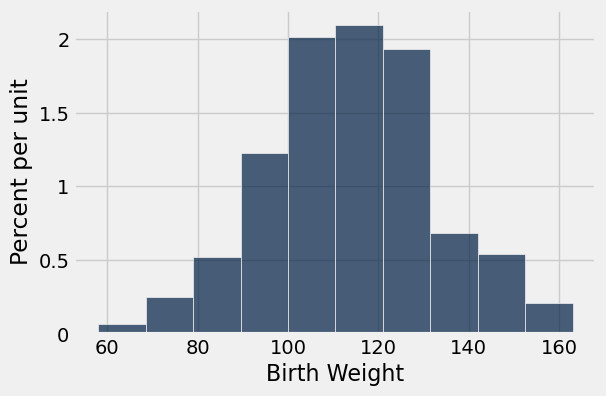

In [8]:
smoking_and_birth_weight.where('Maternal Smoker', True).hist('Birth Weight')

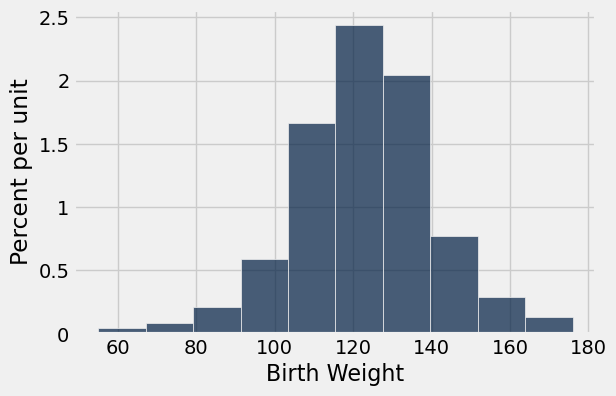

In [9]:
smoking_and_birth_weight.where('Maternal Smoker', False).hist('Birth Weight')

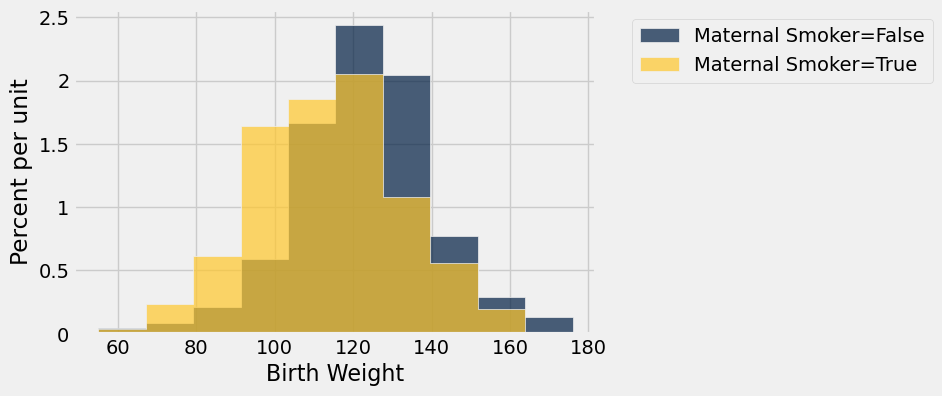

In [10]:
smoking_and_birth_weight.hist('Birth Weight', group='Maternal Smoker')

In [12]:
means_table = smoking_and_birth_weight.group('Maternal Smoker', np.average)
means_table

Maternal Smoker,Birth Weight average
False,123.085
True,113.819


In [15]:
means = means_table.column(1)
observed_difference = means.item(1) - means.item(0)
observed_difference

-9.266142572024918

In [16]:
smoking_and_birth_weight

Maternal Smoker,Birth Weight
False,120
False,113
True,128
True,108
False,136
False,138
False,132
False,120
True,143
False,140


In [17]:
smoking_and_birth_weight.sample(smoking_and_birth_weight.num_rows, with_replacement=False)

Maternal Smoker,Birth Weight
True,139
True,125
True,91
True,140
True,124
True,122
True,103
False,113
False,115
False,143


In [25]:
shuffled_labels = smoking_and_birth_weight.sample(smoking_and_birth_weight.num_rows, with_replacement=False).column(0)
original_and_shuffled = smoking_and_birth_weight.with_column('Shuffled Label', shuffled_labels)
original_and_shuffled

Maternal Smoker,Birth Weight,Shuffled Label
False,120,False
False,113,False
True,128,False
True,108,False
False,136,False
False,138,False
False,132,False
False,120,False
True,143,False
False,140,False


In [28]:
shuffled_only = original_and_shuffled.select('Birth Weight', 'Shuffled Label')
shuffled_group_means = shuffled_only.group('Shuffled Label', np.average)
shuffled_group_means

Shuffled Label,Birth Weight average
False,119.197
True,119.876


In [29]:
def difference_of_means(table, group_label):
    reduced = table.select('Birth Weight', group_label)
    shuffled_group_means = reduced.group(group_label, np.average)
    means = shuffled_group_means.column(1)
    observed_difference = means.item(1) - means.item(0)
    return observed_difference

In [30]:
difference_of_means(original_and_shuffled, 'Maternal Smoker')

-9.266142572024918

In [31]:
difference_of_means(original_and_shuffled, 'Shuffled Label')

0.6786141962612646

In [32]:
def one_simulated_difference_of_means():
    # array of shuffled labels
    shuffled_labels = smoking_and_birth_weight.sample(smoking_and_birth_weight.num_rows, with_replacement=False).column(0)

    # table with birth weights and shuffled labels
    original_and_shuffled = smoking_and_birth_weight.with_column('Shuffled Label', shuffled_labels)

    return difference_of_means(original_and_shuffled, 'Shuffled Label')

In [46]:
one_simulated_difference_of_means()

-0.9561893444246437

In [47]:
differences = make_array()

repetitions = 5000
for i in np.arange(repetitions):
    differences = np.append(differences, one_simulated_difference_of_means())

differences

array([ 1.89130216,  0.03470908,  0.01682283, ..., -0.10838094,
        0.78950897,  0.67503695])